Number of faces detected: 0


Text(0.5, 1.0, 'Rostros')

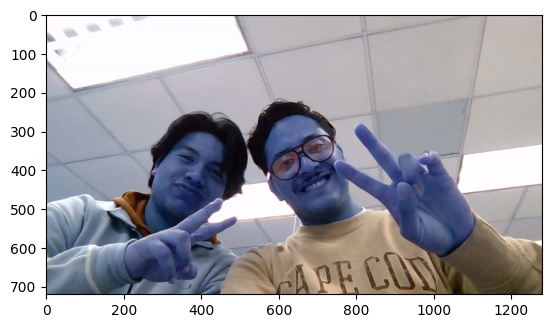

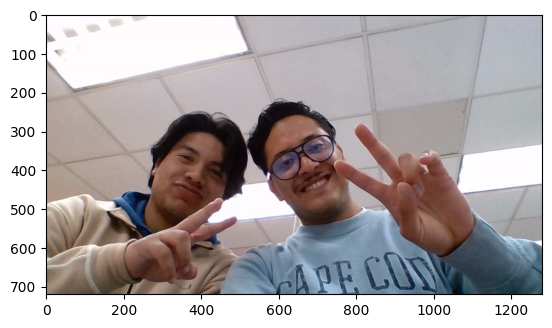

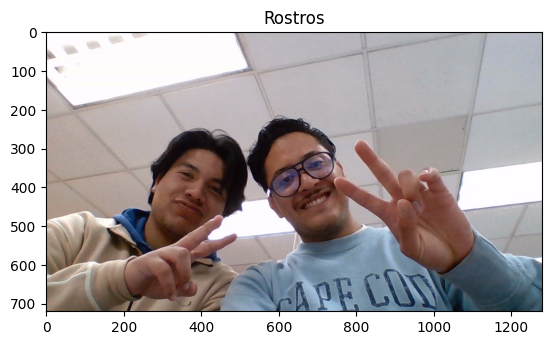

In [1]:
import cv2
import matplotlib.pyplot as plt

# img=cv2.imread(r"D:\Upiita\6to\Patrones\Objetos\himym.jpg")
img=cv2.imread(r"C:\Users\emili\Pictures\Camera Roll\WIN_20241126_18_28_03_Pro.jpg")
# img=cv2.imread(r"C:\Users\emili\Pictures\Camera Roll\WIN_20240927_07_42_23_Pro (2).jpg")

plt.figure()
plt.imshow(img)

img_rgb=cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
plt.figure()
plt.imshow(img_rgb)

gray=cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
plt.figure()
plt.imshow(gray,cmap='gray')

face_cascade=cv2.CascadeClassifier(cv2.data.haarcascades+'haarcascade_frontalface_default.xml')

if face_cascade.empty():
    print('Error:imagen sin rostro')
    exit()

faces=face_cascade.detectMultiScale(gray,scaleFactor=3.5,minNeighbors=30,minSize=(10,10))

print(f"Number of faces detected: {len(faces)}")

img_detect=img_rgb.copy()
for (x,y,w,h) in faces:
    cv2.rectangle(img_detect,(x,y),(x+w,y+h),(255,0,0),2)

plt.imshow(img_detect)
plt.title('Rostros')

In [6]:
#PCA 
import os
import numpy as np
import matplotlib.pyplot as plt
from skimage.io import imread
import random
plt.close('all')

In [4]:

#Generar Base de datos
def cargar_imagenes(personas,fotos_totales,filas=20,columnas=100):
    datos=[]
    etiquetas=[]
    imagenes_muestra=[]
    for i in range(personas):
        carpeta=f"s{i+1}"
        if not os.path.exists(carpeta):
            raise FileNotFoundError(f"No se encontró la carpeta: {carpeta}")
        for j in range(fotos_totales):
            nombre_imagen=os.path.join(carpeta,f"F{j+1}.jpg")
            if not os.path.exists(nombre_imagen):
                raise FileNotFoundError(f"No se encontró la imagen: {nombre_imagen}")
            imagen=imread(nombre_imagen,as_array=True)
            if imagen.shape != (filas,columnas):
                raise ValueError(f"Dimensiones incorrectas en: {nombre_imagen}:{imagen.shape}")
            vector_imagen=imagen.flatten().astype(np.float32)
            datos.append(vector_imagen)
            etiquetas.append(i+1)#personas etiquetadas del 1 al N
            if j==0:
                imagenes_muestra.append(imagen)
    datos=np.array(datos)
    etiquetas=np.array(etiquetas)
    return datos,etiquetas,imagenes_muestra

def Calcular_PCA(datos,num_componentes):
    media=np.mean(datos,axis=0)
    datos_centrados=datos-media
    n_imagenes=datos.shape[0]
    covarianza=np.dot(datos_centrados,datos_centrados.T)
    valores_propios,vectores_propios=np.linalg.eigh(covarianza)
    idx=np.argsort(valores_propios)[::-1]
    valores_propios=valores_propios[idx]
    vectores_propios=vectores_propios[idx]
    vectores_propios=vectores_propios[:,:num_componentes]
    eigenfaces=np.dot(datos_centrados.T,vectores_propios)
    for i in range(eigenfaces.shape[1]):
        eigenfaces[:,i]/=np.linalg.norm(eigenfaces[:,0])
    return media,eigenfaces,valores_propios[:num_componentes],datos_centrados

def proyectar(datos,media,eigenfaces):
    datos_centrados=datos-media
    firmas=np.dot(datos_centrados,eigenfaces)
    return firmas

def reconer(imagen_test,media,eigenfaces,firmas_entreno,etiqueta_entrena):
    firma_test=np.dot((imagen_test-media),eigenfaces)
    distancias=np.linalg.norm(firmas_entreno-firma_test,axis=1)
    idx_min=np.argmin(distancias)
    return idx_min,distancias[idx_min]

def reconstruir_imagen(imagen_centrada,eigenfaces,K,media):
    coef=np.dot(imagen_centrada,eigenfaces[:,:K])
    reconstruir=media+np.dot(coef,eigenfaces)
    return reconstruir
    

In [5]:
personas=5
fotos_totales=7
fotos_entrenamiento=5
fotos_prueba=fotos_totales-fotos_entrenamiento
filas,columnas=120,180
num_componentes=10

datos,etiquetas,imagenes_muestra=cargar_imagenes(personas,fotos_totales,filas,columnas)

fig,axes=plt.subplots(2,5,figsize=(12,5))
axes=axes.ravel()
for i in range (min(10,len(imagenes_muestra))):
    axes[i].imshow(imagenes_muestra[i],cmap='gray')
    axes[i].axis("off")

fig.subtitle("Muestras de Imagenes Originales")
plt.tight_layout()



TypeError: PillowPlugin.read() got an unexpected keyword argument 'as_array'

In [ ]:
# Dividir en entrenamiento y prueba
datos_entreno = []
etiquetas_entreno = []
datos_prueba = []
etiquetas_prueba = []
 
for p in range(personas):
    start = p*fotos_totales
    end = start + fotos_totales
    subset = datos[start:end]
    subset_etiquetas = etiquetas[start:end]
    datos_entreno.append(subset[:fotos_entrenamiento])
    etiquetas_entreno.append(subset_etiquetas[:fotos_entrenamiento])
    datos_prueba.append(subset[fotos_entrenamiento:])
    etiquetas_prueba.append(subset_etiquetas[fotos_entrenamiento:])
 
datos_entreno = np.vstack(datos_entreno)
etiquetas_entreno = np.hstack(etiquetas_entreno)
datos_prueba = np.vstack(datos_prueba)
etiquetas_prueba = np.hstack(etiquetas_prueba)
 
# Calcular PCA manualmente
media, eigenfaces, vals_propios, datos_entreno_centrados = calcular_pca(datos_entreno, num_componentes)
 
# Visualizar la imagen promedio
plt.figure()
plt.imshow(media.reshape(filas, columnas), cmap='gray')
plt.title("Imagen Promedio (Entrenamiento)")
plt.axis('off')
plt.show()

De la base de datos se obtiene un promedio, dicho promedio se resta a las imágenes para determinar una imagen "unica" de cada persona, de dichas imágenes se determinan matrices de covarianza para realizar eigenvectores y ecuaciones de cada persona

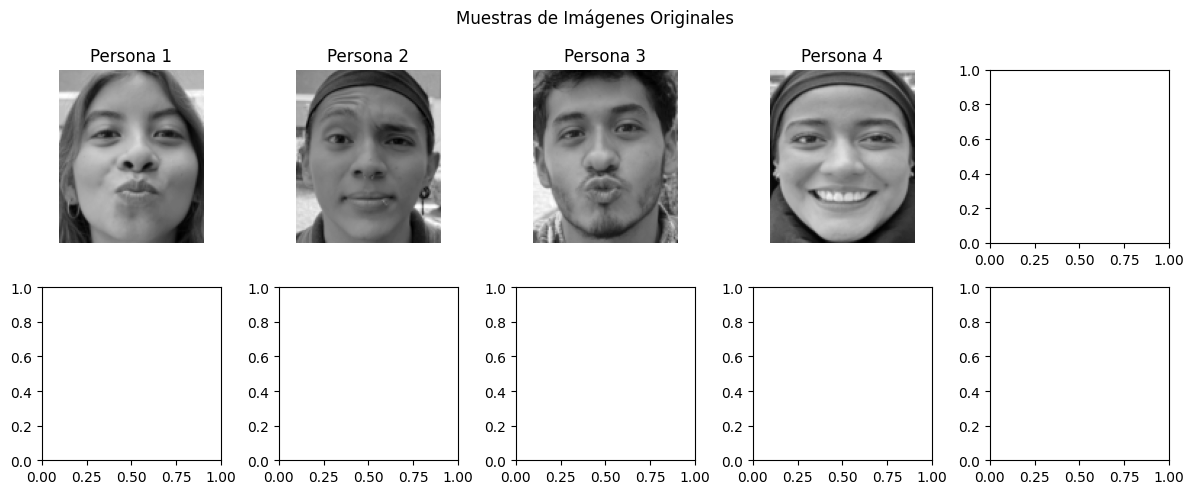

In [18]:
import os
import numpy as np
import matplotlib.pyplot as plt
from skimage.io import imread
from skimage.transform import resize
import random
from sklearn.neighbors import KNeighborsClassifier
plt.close('all')

#------------------------------------------------------------------------------------------------
def cargar_imagenes(personas,fotos_totales,filas=120, columnas = 100):
    datos = []
    etiquetas = []
    imagenes_muestra = []
    
    for i in range(personas):
        carpeta = f"s{i+1}"
        
        if not os.path.exists(carpeta):
            raise FileNotFoundError(f"No se encontro la carpeta:{carpeta}")
        
        for j in range(fotos_totales):
            nombre_imagen = os.path.join(carpeta,f"F{j + 1}.jpg")
            
            if not os.path.exists(nombre_imagen):
                raise FileExistsError(f"No se encontro la imagen: {nombre_imagen}")
            
            imagen = imread(nombre_imagen,as_gray = True)
            imagen = resize(imagen, (120, 100), anti_aliasing=True)
            
            if imagen.shape !=(filas,columnas):
                raise ValueError(f"Dimensiones incorrectas en {nombre_imagen}: {imagen.shape}")
            
            vector_imagen = imagen.flatten().astype(np.float32)
            datos.append(vector_imagen)
            etiquetas.append(i + 1) #Personas etiquetada del 1 al N
            
            if j == 0:
                imagenes_muestra.append(imagen)
                
    datos = np.array(datos)
    etiquetas = np.array(etiquetas)
    
    return datos,etiquetas,imagenes_muestra

def calcular_PCA(datos,num_componentes):
    media = np.mean(datos,axis=0)
    datos_centrados = datos - media
    n_imagenes = datos.shape[0]
    covarianza = np.dot(datos_centrados,datos_centrados.T)
    valores_propios, vectores_propios =np.linalg.eigh(covarianza)
    idx = np.argsort(valores_propios)[::-1]
    valores_propios = valores_propios[idx]
    valores_propios = valores_propios[idx]
    vectores_propios = vectores_propios[:,:num_componentes]
    eigenfaces = np.dot(datos_centrados.T,vectores_propios)
    for i in range(eigenfaces.shape[1]):
        eigenfaces[:,i] = np.linalg.norm(eigenfaces[:,i])
        
    return media,eigenfaces,valores_propios[:num_componentes], datos_centrados

def proyectar(datos,media,eigenfaces):
    datos_centrados = datos - media
    firmas = np.dot(datos_centrados,eigenfaces)
    return firmas

def reconocer(imagen_test,eigenfaces,firmas_entreno,etiquetas_entrena):
    firma_test = np.dot((imagen_test-media),eigenfaces)
    distancias = np.linalg.norm(firmas_entreno-firma_test,axis=1)
    idx_min = np.argmin(distancias)
    return idx_min,distancias[idx_min]

def reconstruir_imagen(imagen_centrada,eigenfaces,k,media):
    coef = np.dot(imagen_centrada,eigenfaces[:,:k])
    recontruir = media + np.dot(coef, eigenfaces[:,:k].T)
    return recontruir

# Parámetros
personas = 4
fotos_totales = 7  # asumiendo 7 imágenes por persona
fotos_entrenamiento = 5
fotos_prueba = fotos_totales - fotos_entrenamiento
filas, columnas = 120, 100
num_componentes = 10
 
# Cargar todas las imágenes
datos, etiquetas, imagenes_muestra = cargar_imagenes(personas, fotos_totales, filas, columnas)
 
# Visualizar algunas imágenes originales
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
axes = axes.ravel()
for i in range(min(10, len(imagenes_muestra))):
    axes[i].imshow(imagenes_muestra[i], cmap='gray')
    axes[i].set_title(f"Persona {i+1}")
    axes[i].axis('off')
fig.suptitle("Muestras de Imágenes Originales")
plt.tight_layout()
plt.show()

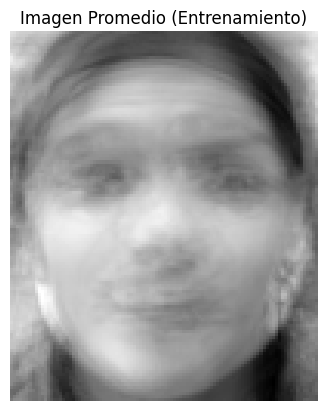

In [19]:
# Dividir en entrenamiento y prueba
datos_entreno = []
etiquetas_entreno = []
datos_prueba = []
etiquetas_prueba = []
 
for p in range(personas):
    start = p*fotos_totales
    end = start + fotos_totales
    subset = datos[start:end]
    subset_etiquetas = etiquetas[start:end]
    datos_entreno.append(subset[:fotos_entrenamiento])
    etiquetas_entreno.append(subset_etiquetas[:fotos_entrenamiento])
    datos_prueba.append(subset[fotos_entrenamiento:])
    etiquetas_prueba.append(subset_etiquetas[fotos_entrenamiento:])
 
datos_entreno = np.vstack(datos_entreno)
etiquetas_entreno = np.hstack(etiquetas_entreno)
datos_prueba = np.vstack(datos_prueba)
etiquetas_prueba = np.hstack(etiquetas_prueba)
 
# Calcular PCA manualmente
media, eigenfaces, vals_propios, datos_entreno_centrados = calcular_PCA(datos_entreno, num_componentes)
 
# Visualizar la imagen promedio
plt.figure()
plt.imshow(media.reshape(filas, columnas), cmap='gray')
plt.title("Imagen Promedio (Entrenamiento)")
plt.axis('off')
plt.show()

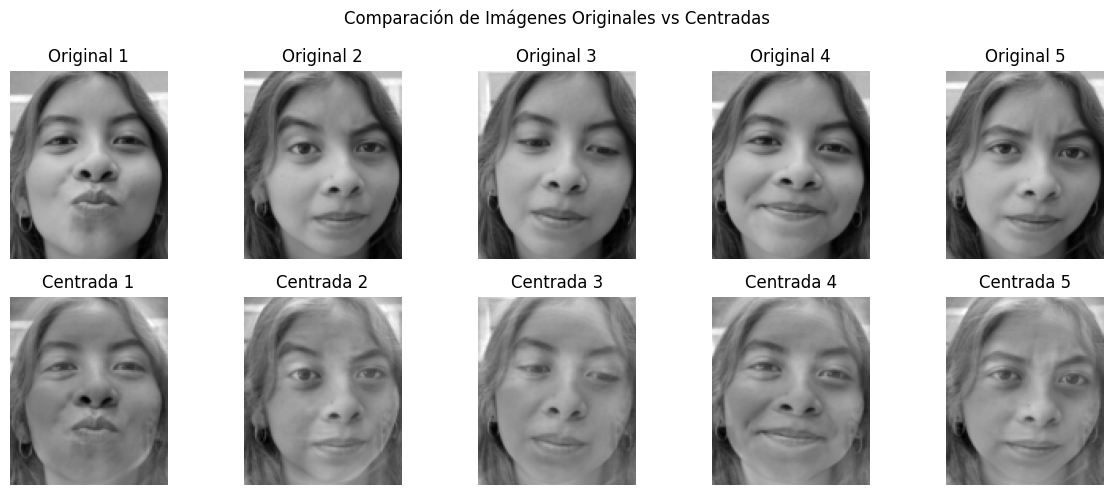

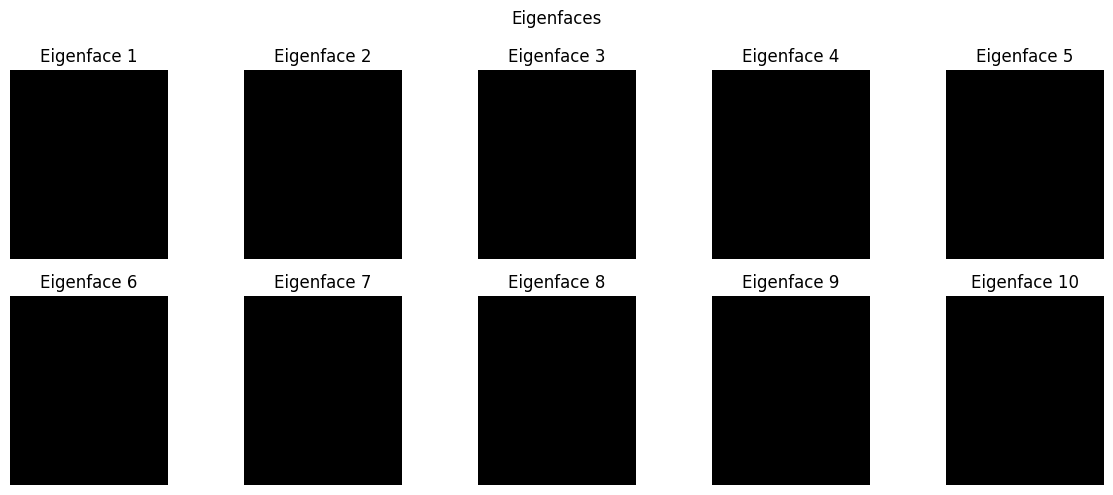

In [20]:
# Visualizar algunas imágenes centradas
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
axes = axes.ravel()
for i in range(5):
    axes[i].imshow(datos_entreno[i].reshape(filas, columnas), cmap='gray')
    axes[i].set_title(f"Original {i+1}")
    axes[i].axis('off')
for i in range(5):
    axes[5+i].imshow(datos_entreno_centrados[i].reshape(filas, columnas), cmap='gray')
    axes[5+i].set_title(f"Centrada {i+1}")
    axes[5+i].axis('off')
fig.suptitle("Comparación de Imágenes Originales vs Centradas")
plt.tight_layout()
plt.show()
 
# Visualizar eigenfaces
fig, axes = plt.subplots(2, 5, figsize=(12,5))
axes = axes.ravel()
for i in range(num_componentes):
    axes[i].imshow(eigenfaces[:, i].reshape(filas, columnas), cmap='gray')
    axes[i].set_title(f"Eigenface {i+1}")
    axes[i].axis('off')
fig.suptitle("Eigenfaces")
plt.tight_layout()
plt.show()

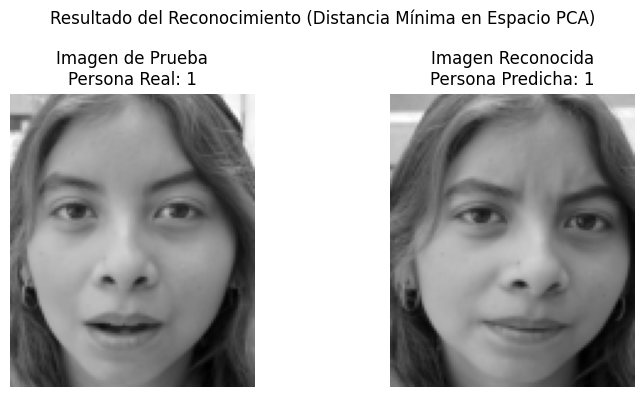

Persona Real: 1, Persona Predicha: 1, Distancia: 220.04


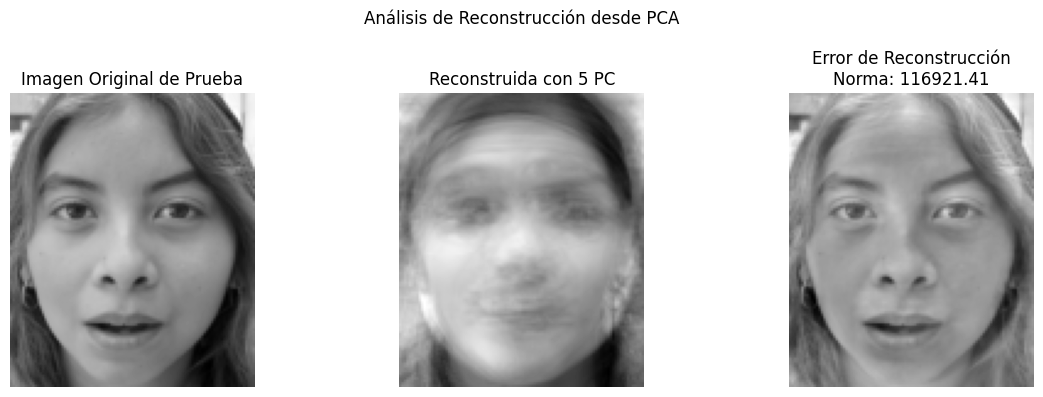

In [21]:
# Proyectar datos
firmas_entreno = proyectar(datos_entreno, media, eigenfaces)
firmas_prueba = proyectar(datos_prueba, media, eigenfaces)
 
# Seleccionar aleatoriamente una imagen de prueba
random_idx = random.randint(0, len(datos_prueba)-1)
imagen_test = datos_prueba[random_idx]
persona_real = etiquetas_prueba[random_idx]
 
# Reconocimiento
idx_reconocida, dist_min = reconocer(imagen_test, eigenfaces, firmas_entreno, etiquetas_entreno)
persona_predicha = etiquetas_entreno[idx_reconocida]
 
# Visualizar resultado del reconocimiento
plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.imshow(imagen_test.reshape(filas, columnas), cmap='gray')
plt.title(f"Imagen de Prueba\nPersona Real: {persona_real}")
plt.axis('off')
 
plt.subplot(1,2,2)
imagen_reconocida = datos_entreno[idx_reconocida]
plt.imshow(imagen_reconocida.reshape(filas, columnas), cmap='gray')
plt.title(f"Imagen Reconocida\nPersona Predicha: {persona_predicha}")
plt.axis('off')
plt.suptitle("Resultado del Reconocimiento (Distancia Mínima en Espacio PCA)")
plt.tight_layout()
plt.show()
 
print(f"Persona Real: {persona_real}, Persona Predicha: {persona_predicha}, Distancia: {dist_min:.2f}")
 
# Visualización adicional: reconstruir una imagen de prueba a partir de las primeras k componentes
k = 5  # Por ejemplo, usar 5 componentes para reconstrucción
imagen_test_centrada = imagen_test - media
imagen_reconstruida = reconstruir_imagen(imagen_test_centrada, eigenfaces, k, media)
 
plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
plt.imshow(imagen_test.reshape(filas, columnas), cmap='gray')
plt.title("Imagen Original de Prueba")
plt.axis('off')
 
plt.subplot(1,3,2)
plt.imshow(imagen_reconstruida.reshape(filas, columnas), cmap='gray')
plt.title(f"Reconstruida con {k} PC")
plt.axis('off')
 
# Mostrar el error de reconstrucción
error = np.linalg.norm(imagen_reconstruida - imagen_test)
plt.subplot(1,3,3)
error_img = (imagen_test - imagen_reconstruida).reshape(filas, columnas)
plt.imshow(error_img, cmap='gray')
plt.title(f"Error de Reconstrucción\nNorma: {error:.2f}")
plt.axis('off')
 
plt.suptitle("Análisis de Reconstrucción desde PCA")
plt.tight_layout()
plt.show()

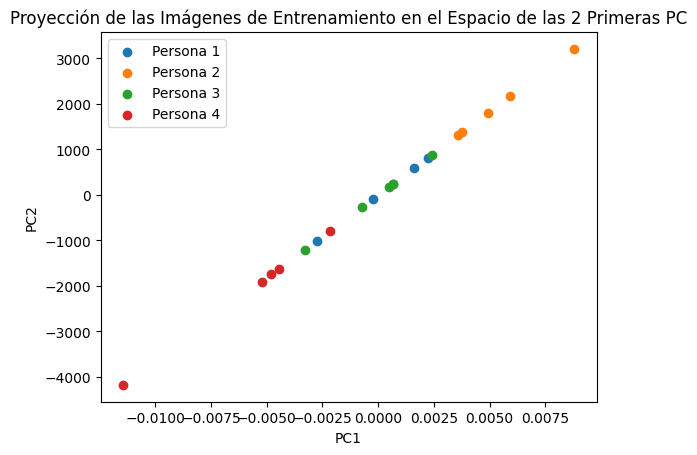

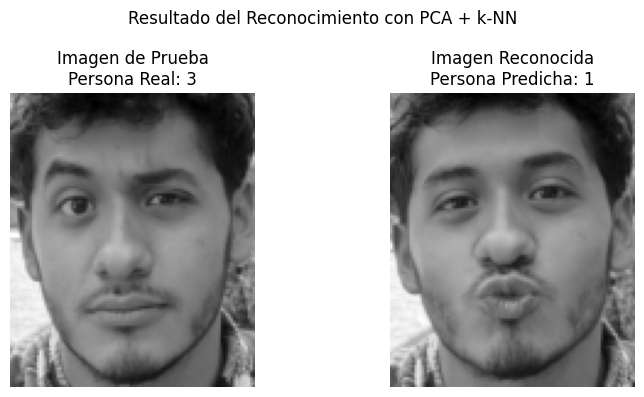

Persona Real: 3, Persona Predicha: 1
Reconocimiento completado.


In [22]:
# Visualizar algunas proyecciones en el espacio PCA (firmas)
# Tomamos las dos primeras componentes y mostramos la distribución de las personas
plt.figure()
for p in range(1, personas+1):
    # Filtramos las firmas de la persona p
    idx_p = (etiquetas_entreno == p)
    plt.scatter(firmas_entreno[idx_p, 0], firmas_entreno[idx_p, 1], label=f'Persona {p}')
plt.title("Proyección de las Imágenes de Entrenamiento en el Espacio de las 2 Primeras PC")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.show()
 
# Entrenar un clasificador k-NN con las firmas de entrenamiento
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(firmas_entreno, etiquetas_entreno)
 
# Seleccionar aleatoriamente una imagen de prueba para verificar reconocimiento
random_index = random.randint(0, len(datos_prueba)-1)
imagen_test = datos_prueba[random_index]
firma_test = firmas_prueba[random_index].reshape(1, -1)
persona_real = etiquetas_prueba[random_index]
 
persona_predicha = knn.predict(firma_test)[0]
 
# Visualizar resultado
# Imagen de prueba
plt.figure(figsize=(8,4))
plt.subplot(1, 2, 1)
plt.imshow(imagen_test.reshape(filas, columnas), cmap='gray')
plt.title(f"Imagen de Prueba\nPersona Real: {persona_real}")
plt.axis('off')
 
# Buscar una imagen del conjunto de entrenamiento más cercana al test (opcional para ver)
distancias, indices = knn.kneighbors(firma_test, n_neighbors=1)
idx_cercano = indices[0, 0]
imagen_reconocida = datos_entreno[idx_cercano]
 
plt.subplot(1, 2, 2)
plt.imshow(imagen_reconocida.reshape(filas, columnas), cmap='gray')
plt.title(f"Imagen Reconocida\nPersona Predicha: {persona_predicha}")
plt.axis('off')
plt.suptitle("Resultado del Reconocimiento con PCA + k-NN")
plt.tight_layout()
plt.show()
 
print(f"Persona Real: {persona_real}, Persona Predicha: {persona_predicha}")
print("Reconocimiento completado.")